# Capstone Project: Pitakado Dataset


# Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Apakah hari event (seperti Valentine dan Birthday) memberikan peningkatan penjualan yang signifikan dibanding hari biasa, dan berapa persen rata-rata peningkatan yang terjadi?
- Pertanyaan 2: Ketika event berlangsung, produk mana yang memberikan profit tertinggi antara kategori Bouquet dan Frame, serta berapa selisih margin keuntungannya?
- Pertanyaan 3: Pada bulan apa terjadi puncak penjualan tertinggi dan terendah dalam periode pencatatan, dan bagaimana pola ini digunakan untuk mengoptimalkan persiapan stok?
- Pertanyaan 4: Bahan baku apa saja yang memiliki total biaya tertinggi dan frekuensi pembelian paling sering, sehingga perlu diprioritaskan dalam manajemen stok untuk efisiensi operasional?

# Import Library/Packages yang Digunakan

In [ ]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data Wrangling

## Gathering Data

Langkah pertama adalah memuat dataset ke dalam environment notebook dengan mengupload file yang telah dikumpulkan dari hasil wawancara bersama pemilik UMKM Pitakado yang berupa data **Penjualan** dan data **Pembelian Bahan Baku** operasional. Kita perlu melihat beberapa baris pertama data untuk mendapatkan gambaran umum mengenai fitur-fitur (kolom) yang tersedia.

Dataset **"UMKM Pitakado Sales & Inventory Tracker"** adalah rekaman data operasional historis dari sebuah bisnis ritel skala kecil menengah (UMKM) yang berfokus pada produk gifting seperti buket bunga, buket snack, dan frame foto.

Dataset ini mencatat pergerakan transaksi harian selama kurang lebih satu kuartal awal (Januari - pertengahan April 2026), termasuk fase persiapan bahan baku di akhir tahun sebelumnya. Fokus utama dari penggunaan data ini adalah untuk menganalisis perputaran kas (cash flow), melacak Harga Pokok Penjualan (HPP) per produk, mengevaluasi margin keuntungan, serta melihat pola permintaan produk yang dipengaruhi oleh hari raya (events).

Berikut adalah rincian dari kedua dataset tersebut:

**1. Dataset Penjualan (Revenue)**

Dataset ini merekam seluruh transaksi masuk dari pelanggan beserta rincian profitabilitas produk.

**Detail Transaksi**
* tanggal: Tanggal terjadinya transaksi penjualan. Digunakan sebagai index waktu (Time-Series) untuk analisis tren.
* produk: Nama atau varian produk kustom yang terjual (contoh: bouquet blue 9 bunga, frame birthday).
* qty: Kuantitas atau jumlah unit produk yang terjual dalam satu transaksi.

**Metrik Finansial**
* Harga_Jual: Total pendapatan kotor (gross revenue) dari produk yang terjual.
* Modal: Estimasi harga pokok produksi atau modal dasar untuk membuat produk tersebut.
* Profit: Keuntungan bersih (net profit) per transaksi, dihitung dari selisih Harga_Jual dikurangi Modal. Ini adalah variabel target penting untuk mengukur kesehatan finansial bisnis.

**Faktor Eksternal (Musiman)**
* is_event: Indikator boolean (TRUE/FALSE) yang menandakan apakah tanggal penjualan bertepatan dengan suatu perayaan.
* event_type: Jenis perayaan spesifik pada hari tersebut (contoh: Valentine, Idul Fitri, Tahun Baru Imlek). Fitur ini sangat krusial untuk menganalisis anomali atau lonjakan permintaan yang bersifat musiman.

**2. Dataset Pembelian Bahan Baku (Expenses)**

Dataset ini mencatat seluruh pengeluaran inventaris yang digunakan sebagai material dasar pembuatan produk UMKM.

**Detail Material**
* tanggal: Tanggal dilakukannya restock atau pembelian bahan baku.
* nama_barang: Nama asli material yang dibeli (contoh: kertas cellophane, lem tembak).
* material_id: Kode unik standar dari material tersebut, mempermudah pengelompokan data pada database (contoh: Kertas_Cellophane).
* unit_type: Satuan ukuran logistik material (contoh: lembar, batang, roll, pack).
* qty: Jumlah unit material yang dibeli.

**Metrik Finansial Pengeluaran**
* harga_satuan: Harga beli dasar untuk satu unit material.
* total_harga: Total pengeluaran kas (cash outflow) untuk item tersebut pada hari pencatatan. Diperoleh dari perkalian qty dengan harga_satuan.

In [ ]:
df_jual = pd.read_csv(f'https://drive.google.com/uc?export=download&id=1jRZbHudKcYQ8kKROVZm9KJ7S4YpAmtc4')
df_jual

,tanggal,produk,qty,Harga_Jual,Modal,Profit,is_event,event_type
0,01/01/2026,NaN,NaN,NaN,NaN,NaN,True,Tahun Baru Masehi
1,02/01/2026,NaN,NaN,NaN,NaN,NaN,False,NaN
2,03/01/2026,NaN,NaN,NaN,NaN,NaN,False,NaN
3,04/01/2026,NaN,NaN,NaN,NaN,NaN,False,NaN
4,05/01/2026,bouquet blue 9 bunga,1.0,135000.0,67000.0,68000.0,False,NaN
...,...,...,...,...,...,...,...,...
126,10/04/2026,NaN,NaN,NaN,NaN,NaN,False,NaN
127,11/04/2026,NaN,NaN,NaN,NaN,NaN,False,NaN
128,12/04/2026,NaN,NaN,NaN,NaN,NaN,False,NaN
129,13/04/2026,NaN,NaN,NaN,NaN,NaN,False,NaN


In [ ]:
df_beli = pd.read_csv(f'https://drive.google.com/uc?export=download&id=1G-5Jipu1nbY0hiD3uYG9kMhxLhYpTl5H')
df_beli

,tanggal,nama_barang,material_id,unit_type,qty,harga_satuan,total_harga
0,20/12/2025,kertas cellophane,Kertas_Cellophane,lembar,50,1500,75000
1,20/12/2025,lem tembak,Lem_Tembak,batang,30,1000,30000
2,20/12/2025,tusuk sate,Tusuk_Sate,pack,5,5000,25000
3,20/12/2025,pita satin,Pita_Satin,roll,10,5000,50000
4,21/12/2025,kawat bulu,Kawat_Bulu,pack,5,15000,75000
...,...,...,...,...,...,...,...
62,09/04/2026,solatip kecil,Solatip_Kecil,roll,1,2000,2000
63,10/04/2026,kertas cellophane,Kertas_Cellophane,lembar,10,1500,15000
64,11/04/2026,lem tembak,Lem_Tembak,batang,5,1000,5000
65,13/04/2026,bunga palsu,Bunga_Palsu,tangkai,1,15000,15000


## Assessing Data

Setelah data berhasil dikumpulkan, langkah selanjutnya adalah melakukan penilaian (assessing) untuk mengidentifikasi masalah kualitas dalam dataset. Pemeriksaan ini mencakup aspek-aspek berikut:

1. **Pemeriksaan Tipe Data**. Kita perlu memastikan bahwa setiap kolom memiliki tipe data yang sesuai dengan isinya (misalnya, kolom tanggal harus bertipe `datetime`, bukan `object`).

2. **Pemeriksaan Missing Values**. Mengecek keberadaan nilai yang hilang (*null/NaN*) di setiap kolom. Hal ini penting karena nilai yang kosong dapat memengaruhi hasil analisis dan performa model machine learning.

3. **Pemeriksaan Data Duplikat**. Mengidentifikasi apakah terdapat baris data yang berulang secara identik dalam dataset yang dapat menyebabkan bias pada hasil statistik.

4. **Ringkasan Parameter Statistik:**. Melihat distribusi data melalui ringkasan statistik (seperti mean, median, min, max, dan kuartil) untuk mendeteksi adanya anomali atau nilai ekstrem (*outliers*).

### df_jual

In [ ]:
df_jual.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 131 entries, 0 to 130
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   tanggal     131 non-null    object 
 1   produk      75 non-null     object 
 2   qty         75 non-null     float64
 3   Harga_Jual  75 non-null     float64
 4   Modal       75 non-null     float64
 5   Profit      75 non-null     float64
 6   is_event    131 non-null    bool   
 7   event_type  18 non-null     object 
dtypes: bool(1), float64(4), object(3)
memory usage: 7.4+ KB


**Inkonsistensi Tipe Data**.
* **`tanggal`**: Kolom ini awalnya terbaca dengan tipe data `object` (string). Seharusnya kolom ini bertipe `datetime` agar dapat digunakan untuk analisis deret waktu (time-series) dan mempermudah ekstraksi fitur waktu seperti bulan atau hari.
* **`Harga_Jual`, `Modal`, dan `Profit`**: Beberapa kolom metrik finansial ini berisiko terbaca sebagai `object` atau `float`. Seharusnya tipe data pada kolom-kolom ini diseragamkan menjadi integer (`int64`) agar konsisten dan mencegah terjadinya *error* saat melakukan operasi perhitungan agregasi atau statistik matematis.

**Masalah Kualitas Data (Missing Values)**

Ditemukan adanya nilai yang hilang (missing values) dengan proporsi yang cukup besar pada dua kolom berikut:
* **`is_event`**: Terdapat 121 baris data yang kosong (hanya 10 baris non-null dari total 131 baris). Kekosongan ini terjadi karena pencatatan aslinya hanya memberikan penanda `TRUE` pada hari-hari yang memang memiliki perayaan/event tertentu.
* **`event_type`**: Terdapat 121 baris data yang kosong (10 non-null dari 131 baris). Pola kekosongan ini selaras dengan kolom `is_event`, di mana hari biasa yang tidak memiliki perayaan tidak memiliki keterangan teks apa pun.

**Ringkasan Struktur Data**
* Dataset Penjualan ini terdiri dari **131 entri** (baris transaksi) dan **8 kolom** utama (sebelum dilakukan *feature engineering*).
* Komposisi tipe data pada awalnya terdiri dari perpaduan angka (`int64`/`float64`) untuk kolom metrik kuantitas dan finansial, serta teks (`object`) untuk nama produk, tanggal, dan nama event. Tidak ditemukan adanya duplikasi baris data yang tidak wajar pada dataset ini.

In [ ]:
df_jual.isna().sum()

,0
tanggal,0
produk,56
qty,56
Harga_Jual,56
Modal,56
Profit,56
is_event,0
event_type,113


In [ ]:
df_jual.duplicated().sum()

np.int64(0)

In [ ]:
df_jual.describe()

,qty,Harga_Jual,Modal,Profit
count,75.000000,75.000000,75.000000,75.000000
mean,1.146667,99960.000000,54706.666667,45253.333333
std,0.895836,93345.976621,48432.949844,48095.932663
min,1.000000,38000.000000,15000.000000,20000.000000
25%,1.000000,55000.000000,25000.000000,28500.000000
50%,1.000000,78000.000000,35000.000000,33000.000000
75%,1.000000,112500.000000,67000.000000,43000.000000
max,7.000000,650000.000000,321000.000000,329000.000000


In [ ]:
# 1. Melihat daftar semua nama produk unik
df_jual['produk'].unique()

array([nan, 'bouquet blue 9 bunga ', 'boquet costum rokok ',
       'bouquet snack tango ', 'bouquet red flower ',
       'bouquet bunga mix snack top ', 'frame birthday ',
       'frame birthday besar ', 'bouquet model koran tumbelina mini ',
       'bouquet kopi ', 'bouquet bang bang mix rokok ',
       'bouquet motif koran ', 'bouquet costum foto ',
       'bouquet snack sip ', 'bouquet warna ungu medium ',
       'bouquet silverqueen ', 'bouquet jumbo mawar 100 pc ',
       'bouquet costum jepit kamboja ', 'bouquet flower medium red ',
       'bouquet snack coklat mini ', 'frame valentine ',
       'bouquet bunga coklat 3 ', 'bouquet silverqueen mini 4 ',
       'bouquet snack  ', 'bouquet kopi inc bunga mini ',
       'bouquet costum merah ', 'bouquet snack bangbang ',
       'bouquet koran medium ', 'bouquet koran tumbelinna ',
       'bouquet pocky ', 'bouquet koran costum isi 3bunga ',
       'frame valentine besar ', 'frame besar',
       'bouquet flower medium unggu ', 'frame

In [ ]:
# 2. Melihat produk apa saja yang paling sering muncul beserta frekuensinya

df_jual['produk'].value_counts().head(20)

,count
produk,
frame birthday,11
frame birthday besar,2
frame valentine,2
bouquet silverqueen,2
money bouquet,2
bouquet tumbelina koran,2
bouquet rose isi 9,2
bucket sip,2
boquet costum rokok,1


### df_beli

In [ ]:
df_beli.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   tanggal       67 non-null     object
 1   nama_barang   67 non-null     object
 2   material_id   67 non-null     object
 3   unit_type     67 non-null     object
 4   qty           67 non-null     int64 
 5   harga_satuan  67 non-null     int64 
 6   total_harga   67 non-null     int64 
dtypes: int64(3), object(4)
memory usage: 3.8+ KB


In [ ]:
df_beli.isna().sum()

,0
tanggal,0
nama_barang,0
material_id,0
unit_type,0
qty,0
harga_satuan,0
total_harga,0


In [ ]:
df_beli.duplicated().sum()

np.int64(0)

In [ ]:
df_beli.describe()

,qty,harga_satuan,total_harga
count,67.000000,67.000000,67.000000
mean,7.029851,4537.313433,17686.567164
std,8.133303,4695.511584,21965.681880
min,1.000000,1000.000000,2000.000000
25%,1.000000,1500.000000,5000.000000
50%,5.000000,2000.000000,10000.000000
75%,10.000000,5000.000000,20000.000000
max,50.000000,15000.000000,150000.000000


Dataset `df_beli` sudah bersih karna hanya memiliki data yang berupa pembelian bahan baku yang tidak selalu dilakukan setiap harinya dan hanya dibeli pada saat bahan sudah mulai kurang, maka dari itu tidak ada nilai yang kosong dan duplikat, semua tipe data sudah sesuai, dan sebaran nilai dan skalanya tidak ada yang mencurigakan.

## Cleaning Data

Setelah mengidentifikasi beberapa isu teknis pada tahap *Assessing Data*, langkah krusial selanjutnya adalah melakukan pembersihan data (data cleaning). Proses ini bertujuan untuk menstandardisasi format, memperbaiki tipe data yang keliru, serta menangani nilai yang kosong agar kedua dataset (Penjualan dan Pembelian) siap untuk dieksplorasi lebih lanjut.

---

**1. Memperbaiki dan Menstandardisasi Tipe Data**
* **Kolom Tanggal**: Masalah utama ditemukan pada kolom `tanggal` di kedua dataset yang masih terbaca sebagai string (`object`). Kita harus mengonversinya menjadi tipe `datetime` agar bisa diurutkan secara kronologis dan diekstrak menjadi fitur waktu (bulan, hari).
* **Kolom Metrik Finansial**: Kolom seperti `Harga_Jual`, `Modal`, `Profit`, dan `total_harga` perlu dipastikan berformat integer numerik (`int64`). Ini untuk menghindari *error* perhitungan matematis dan memastikan keakuratan agregasi arus kas.
* **Standardisasi Teks**: Untuk mencegah terbaca sebagai produk atau barang yang berbeda akibat kesalahan ketik (*typo*) atau penggunaan huruf besar/kecil yang tidak konsisten, kita akan menyeragamkan kolom `produk` dan `nama_barang` menjadi huruf kecil (lowercase) dan menghapus spasi berlebih.

**2. Menangani Nilai Kosong (Missing Values)**

Pada dataset Pembelian (`beli_df`) tidak ditemukan nilai kosong, sehingga kita fokus pada dataset Penjualan (`jual_df`):
* **Kolom** `is_event` **dan** `event_type`: Kekosongan yang besar pada kolom ini bukanlah sebuah *error*, melainkan karena hari tanpa perayaan dibiarkan kosong. Strategi penanganannya adalah melakukan imputasi dengan nilai default: mengisi baris yang kosong pada `is_event` dengan `FALSE`, dan pada `event_type` dengan tanda setrip (`-`).


In [ ]:
# 1. PEMBERSIHAN TANGGAL SECARA ABSOLUT
# Parameter format='mixed' dan dayfirst=True akan memaksa Pandas pintar mengenali format apapun
df_jual['tanggal'] = pd.to_datetime(df_jual['tanggal'], format='mixed', dayfirst=True, errors='coerce')
df_beli['tanggal'] = pd.to_datetime(df_beli['tanggal'], format='mixed', dayfirst=True, errors='coerce')

# Jika ada tanggal yang kosong (NaN), gunakan ffill (Forward Fill)
df_jual['tanggal'] = df_jual['tanggal'].ffill()
df_beli['tanggal'] = df_beli['tanggal'].ffill()

# BUANG baris yang tanggalnya benar-benar rusak / NaT (Not a Time)
df_jual = df_jual.dropna(subset=['tanggal'])
df_beli = df_beli.dropna(subset=['tanggal'])

print("Rentang Data Penjualan: ", df_jual['tanggal'].min().strftime('%d %b %Y'), "-", df_jual['tanggal'].max().strftime('%d %b %Y'))
print("Rentang Data Pembelian: ", df_beli['tanggal'].min().strftime('%d %b %Y'), "-", df_beli['tanggal'].max().strftime('%d %b %Y'))

Rentang Data Penjualan:  01 Jan 2026 - 14 Apr 2026
Rentang Data Pembelian:  20 Dec 2025 - 14 Apr 2026


In [ ]:
# 2. PEMBERSIHAN TIPE DATA NUMERIK (UANG & QTY)
for col in ['Harga_Jual', 'Modal', 'Profit', 'qty']:
    df_jual[col] = pd.to_numeric(df_jual[col], errors='coerce').fillna(0).astype('int64')

for col in ['harga_satuan', 'total_harga', 'qty']:
    df_beli[col] = pd.to_numeric(df_beli[col], errors='coerce').fillna(0).astype('int64')

In [ ]:
# 3. BUANG BARIS SAMPAH / BUKAN TRANSAKSI (misal: baris tulisan "JANUARI")
# Hapus baris jika nama produknya kosong atau 0
df_jual = df_jual.dropna(subset=['produk'])
df_jual = df_jual[df_jual['produk'].astype(str).str.strip() != '']
df_jual = df_jual[df_jual['produk'] != '0'] # berjaga-jaga jika 0 terbaca sebagai produk

In [ ]:
# 4. WAJIB: URUTKAN TANGGAL DARI TERLAMA KE TERBARU
df_jual = df_jual.sort_values('tanggal').reset_index(drop=True)
df_beli = df_beli.sort_values('tanggal').reset_index(drop=True)

In [ ]:
# Ekstraksi fitur tambahan untuk amannya
df_jual['is_event'] = df_jual.get('is_event', pd.Series([False]*len(df_jual))).fillna(False)

print("Berhasil! Rentang Tanggal Penjualan:", df_jual['tanggal'].min().strftime('%d %b %Y'), "s/d", df_jual['tanggal'].max().strftime('%d %b %Y'))
print("Berhasil! Rentang Tanggal Pembelian:", df_beli['tanggal'].min().strftime('%d %b %Y'), "s/d", df_beli['tanggal'].max().strftime('%d %b %Y'))

Berhasil! Rentang Tanggal Penjualan: 05 Jan 2026 s/d 09 Apr 2026
Berhasil! Rentang Tanggal Pembelian: 20 Dec 2025 s/d 14 Apr 2026


In [ ]:
df_jual

,tanggal,produk,qty,Harga_Jual,Modal,Profit,is_event,event_type
0,2026-01-05,bouquet blue 9 bunga,1,135000,67000,68000,False,NaN
1,2026-01-08,boquet costum rokok,1,128000,74000,54000,False,NaN
2,2026-01-09,bouquet snack tango,1,50000,30000,20000,False,NaN
3,2026-01-11,bouquet red flower,1,74000,42000,32000,False,NaN
4,2026-01-11,bouquet bunga mix snack top,1,75000,48000,27000,False,NaN
...,...,...,...,...,...,...,...,...
70,2026-04-05,bucket costum rokok,1,128000,72000,56000,True,Paskah
71,2026-04-07,frame costum,1,78000,35000,43000,False,NaN
72,2026-04-08,bucket sip,1,45000,25000,20000,False,NaN
73,2026-04-09,bucket isi 9 bunga,1,135000,67000,68000,False,NaN


In [ ]:
df_beli.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   tanggal       67 non-null     datetime64[ns]
 1   nama_barang   67 non-null     object        
 2   material_id   67 non-null     object        
 3   unit_type     67 non-null     object        
 4   qty           67 non-null     int64         
 5   harga_satuan  67 non-null     int64         
 6   total_harga   67 non-null     int64         
dtypes: datetime64[ns](1), int64(3), object(3)
memory usage: 3.8+ KB


# Exploratory Data Analysis (EDA)

Tujuan utama dari tahap ini adalah untuk memahami distribusi data, mendeteksi korelasi antar variabel, dan mencari wawasan (insights) awal yang dapat menjawab hipotesis kita mengenai pola tren penjualan berdasarkan data historis.

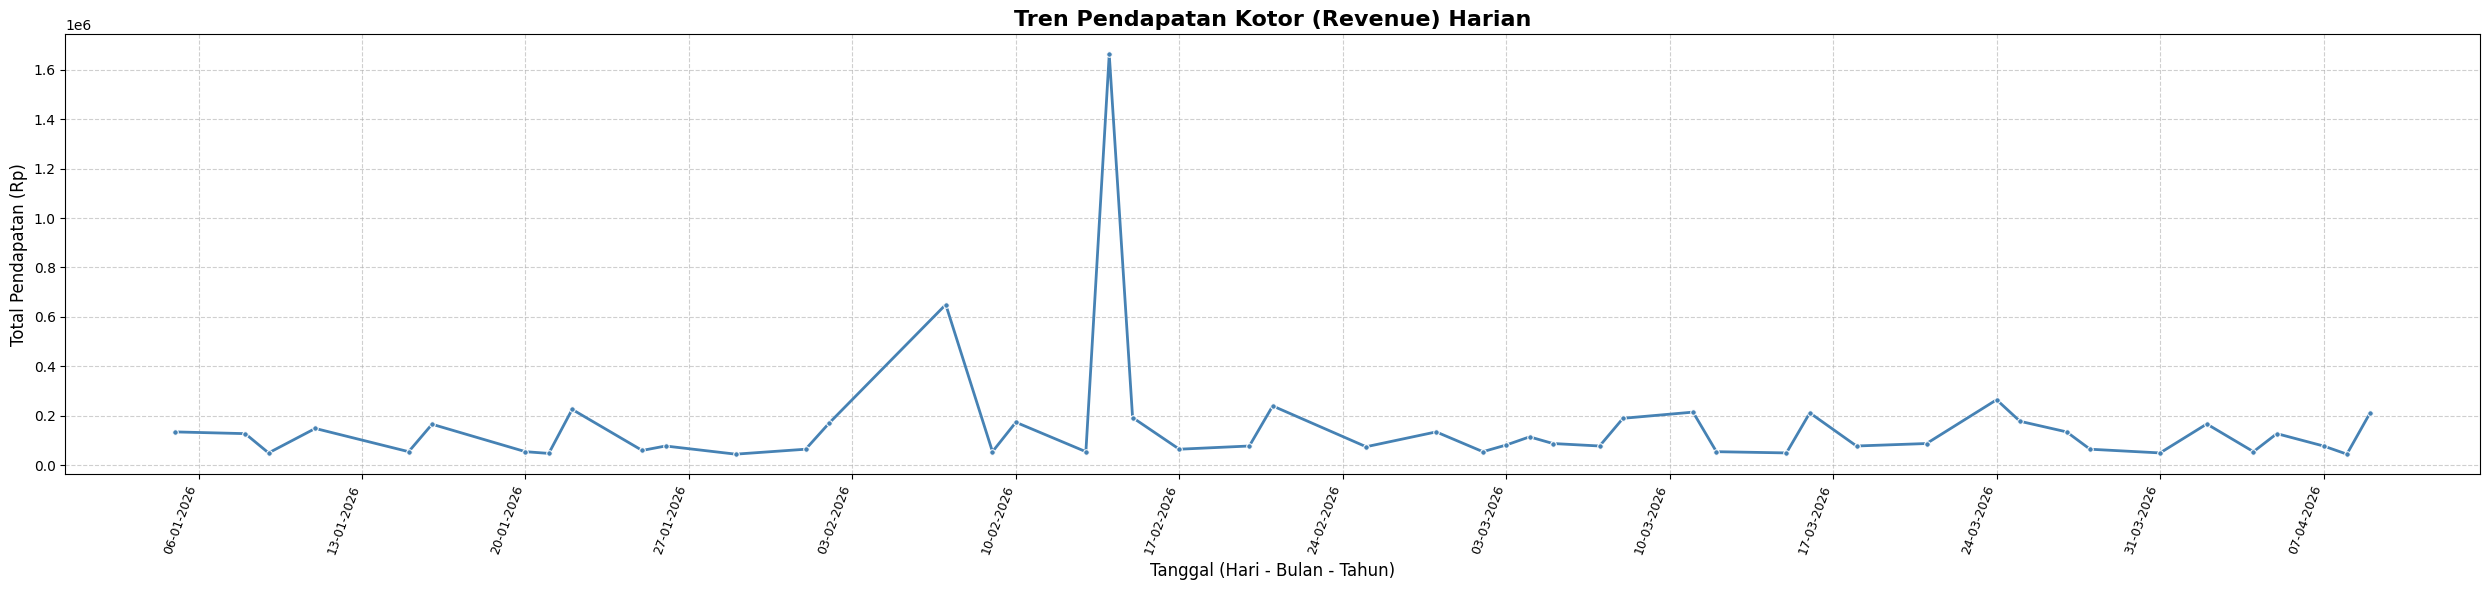


📅 Rentang data: 05 Jan 2026 - 09 Apr 2026


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates

# Agregasi pendapatan harian
daily_revenue = df_jual.groupby('tanggal')['Harga_Jual'].sum().reset_index()
daily_revenue = daily_revenue.sort_values('tanggal')

# Membuat figure lebih lebar agar tanggal tidak bertumpuk
plt.figure(figsize=(25, 6))

# Buat line plot
sns.lineplot(data=daily_revenue, x='tanggal', y='Harga_Jual',
             color='steelblue', linewidth=2, marker='o', markersize=4)

# FORMAT TANGGAL LENGKAP (HARI - BULAN - TAHUN)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d-%m-%Y'))
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))

plt.title('Tren Pendapatan Kotor (Revenue) Harian', fontsize=16, fontweight='bold')
plt.xlabel('Tanggal (Hari - Bulan - Tahun)', fontsize=12)
plt.ylabel('Total Pendapatan (Rp)', fontsize=12)

# Rotasi label agar tidak bertumpuk
plt.xticks(rotation=70, ha='right', fontsize=9)

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print(f"\n📅 Rentang data: {daily_revenue['tanggal'].min().strftime('%d %b %Y')} - {daily_revenue['tanggal'].max().strftime('%d %b %Y')}")

Grafik di atas adalah *line chart* (diagram garis) yang memvisualisasikan pergerakan arus kas harian UMKM Pitakado selama periode pertengahan Desember 2025 hingga awal April 2026. Sumbu X merepresentasikan garis waktu (tanggal transaksi), sedangkan sumbu Y merepresentasikan nominal uang dalam skala Rupiah.

Untuk menjaga konsistensi visual, grafik ini menggunakan satu tema warna utama (*steelblue*), namun membedakan dua metrik finansial melalui gaya garis dan marker:

**Total Pengeluaran Bahan (Garis Putus-putus dengan Marker 'x')**
* **Fase Belanja Modal (Desember):** Di awal grafik (sekitar akhir Desember 2025), terlihat lonjakan garis pengeluaran yang tidak diikuti oleh adanya garis profit. Ini secara visual memvalidasi adanya fase persiapan bisnis di mana UMKM melakukan pengadaan inventaris/stok bahan baku secara masif sebelum benar-benar berjualan.
* **Fase Maintenance (Januari - April):** Setelah fase awal tersebut, garis pengeluaran cenderung mendatar (*flat*) di angka nominal yang rendah. Ini menunjukkan bahwa aktivitas belanja di bulan-bulan berikutnya hanyalah pengeluaran rutin dalam skala kecil untuk *restock* barang yang cepat habis (seperti kertas *cellophane* atau lem tembak).


**Total Profit Masuk (Garis Solid dengan Marker Bulat)**
* **Kondisi Hari Biasa (Normal Days):** Sepanjang bulan Januari hingga awal Februari, garis profit bergerak di area bawah yang cukup stabil. Angkanya relatif kecil, menunjukkan ritme penjualan reguler di hari-hari tanpa perayaan.
* **Lonjakan Musiman (Spike):** Terdapat dua lonjakan profit yang sangat tajam dan ekstrem:
   * **Puncak Pertama (Pertengahan Februari):** Terjadi lonjakan tajam hingga melampaui angka Rp1.000.000 dalam satu hari. Titik ini bertepatan dengan momen perayaan Valentine.
   * **Puncak Kedua (Pertengahan - Akhir Maret):** Terjadi fluktuasi naik yang cukup signifikan di periode ini, yang bertepatan dengan momentum **Idul Fitri / Lebaran**.

**Kesimpulan Utama (Key Insight):**
Visualisasi ini dengan sangat jelas membuktikan bahwa UMKM Pitakado adalah model bisnis yang sangat didorong oleh momentum (*event-driven business*). Keuntungan terbesar dalam satu kuartal tidak didapatkan dari penjualan stabil setiap hari, melainkan terkumpul secara masif pada beberapa hari tertentu yang merupakan hari libur atau perayaan besar.

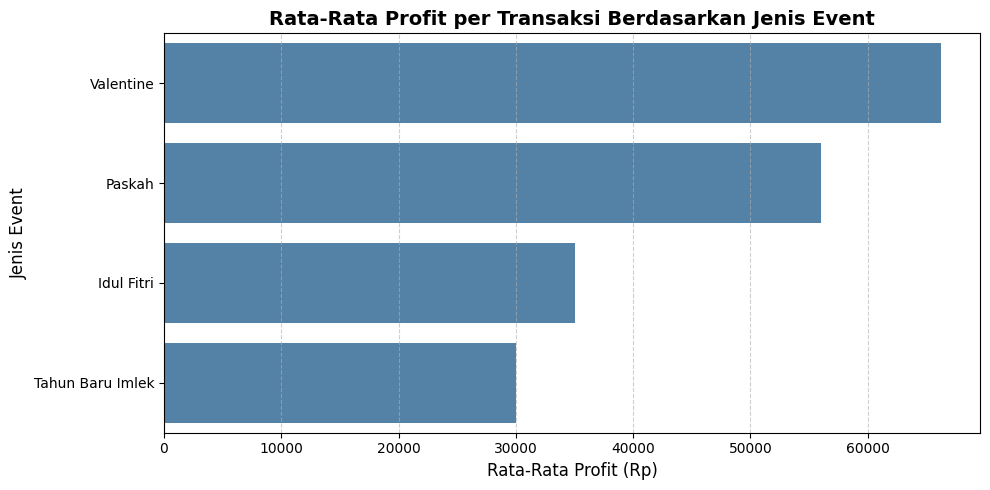

In [ ]:
# Agregasi rata-rata profit berdasarkan jenis event
event_profit = df_jual.groupby('event_type')['Profit'].mean().reset_index().sort_values('Profit', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=event_profit, x='Profit', y='event_type', color='steelblue')
plt.title('Rata-Rata Profit per Transaksi Berdasarkan Jenis Event', fontsize=14, fontweight='bold')
plt.xlabel('Rata-Rata Profit (Rp)', fontsize=12)
plt.ylabel('Jenis Event', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Grafik batang horizontal (*horizontal bar chart*) ini memvisualisasikan perbandingan rata-rata keuntungan bersih (*profit*) per transaksi yang didapatkan berdasarkan momentum atau jenis perayaannya. Sumbu X merepresentasikan nominal uang (Rupiah), sedangkan sumbu Y mengategorikan jenis harinya.

**Puncak Profitabilitas (Valentine & Paskah)**

* Grafik ini dengan jelas menunjukkan bahwa pesanan pada hari **Valentine** menghasilkan rata-rata profit tertinggi, menyentuh angka lebih dari **Rp60.000 per transaksi**. Di posisi kedua, secara mengejutkan, momen **Paskah** juga mencatatkan profit rata-rata yang sangat tinggi (di atas Rp50.000). Hal ini mengindikasikan bahwa pada kedua perayaan ini, pelanggan cenderung memesan produk premium berukuran besar.

**Profitabilitas Menengah (Idul Fitri & Imlek)**

* Perayaan Idul Fitri dan Tahun Baru Imlek berada di urutan bawah dengan rata-rata profit di kisaran **Rp30.000 - Rp35.000 per transaksi**. Pada momen ini, pelanggan kemungkinan lebih sering membeli hampers/produk berukuran standar yang dibagikan secara massal (kuantitas banyak namun margin per item lebih kecil).

**Kesimpulan Utama (Key Insight):**
Tidak semua event diciptakan sama. Momen yang bersifat personal/romantis (seperti Valentine) terbukti membuat pelanggan jauh lebih tidak sensitif terhadap harga (*price-insensitive*) dibandingkan momen perayaan komunal. UMKM harus memprioritaskan penawaran produk bernilai tinggi (*high-ticket items*) khusus di minggu-minggu Valentine.

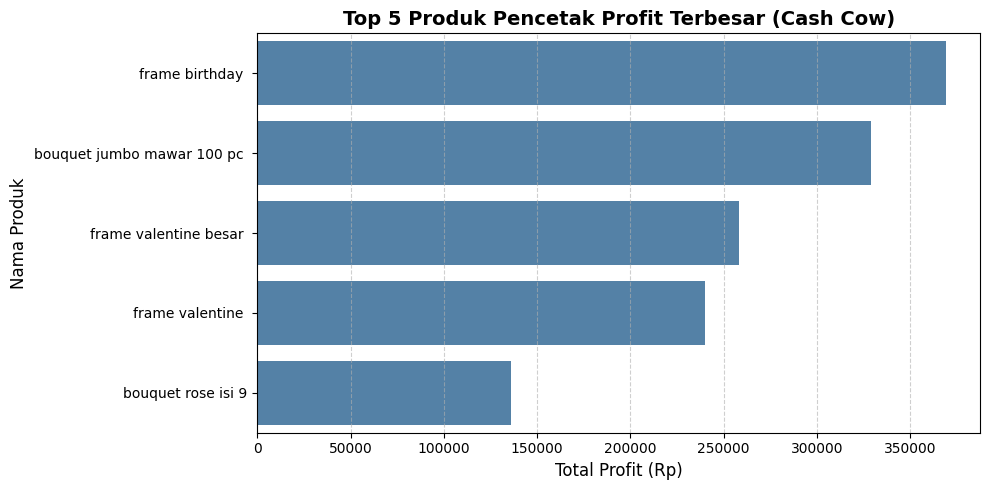

In [ ]:
# Agregasi total profit berdasarkan produk
top_profit_products = df_jual.groupby('produk')['Profit'].sum().reset_index().sort_values('Profit', ascending=False).head(5)

plt.figure(figsize=(10, 5))
sns.barplot(data=top_profit_products, x='Profit', y='produk', color='steelblue')
plt.title('Top 5 Produk Pencetak Profit Terbesar (Cash Cow)', fontsize=14, fontweight='bold')
plt.xlabel('Total Profit (Rp)', fontsize=12)
plt.ylabel('Nama Produk', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Grafik batang ini memetakan lima produk penyumbang uang bersih (profit) akumulatif paling besar ke dalam kas UMKM. Sumbu X menunjukkan total profit (dalam skala ratusan ribu Rupiah).


**Frame Birthday Sebagai Tulang Punggung**
* Berbeda dengan asumsi awal bahwa produk Valentine akan merajai segalanya, **frame birthday** justru keluar sebagai pencetak uang nomor satu (menyumbang hampir **Rp370.000** profit bersih). Ini sangat logis karena ulang tahun adalah event yang terjadi setiap hari sepanjang tahun, tidak terpaku pada satu musim saja.

**Kategori Produk Premium**
* Di urutan kedua terdapat **bouquet jumbo mawar 100 pc** (menyumbang sekitar Rp330.000). Meskipun buket ini mungkin sangat jarang terjual (kuantitas rendah), margin keuntungan per satu unitnya sangat raksasa sehingga langsung melesat ke posisi atas. Posisi selanjutnya didominasi oleh varian *frame valentine* dan *bouquet rose*.

**Kesimpulan Utama (Key Insight):**
Fokus utama marketing harian (di luar hari raya) harus selalu diarahkan pada produk *Frame Birthday*. Sementara itu, UMKM juga wajib mempertahankan katalog *Bouquet Jumbo* sebagai senjata rahasia (Cash Cow) karena satu kali saja pesanan ini masuk (misal untuk acara lamaran/aniversari), keuntungannya setara dengan menjual puluhan produk biasa.

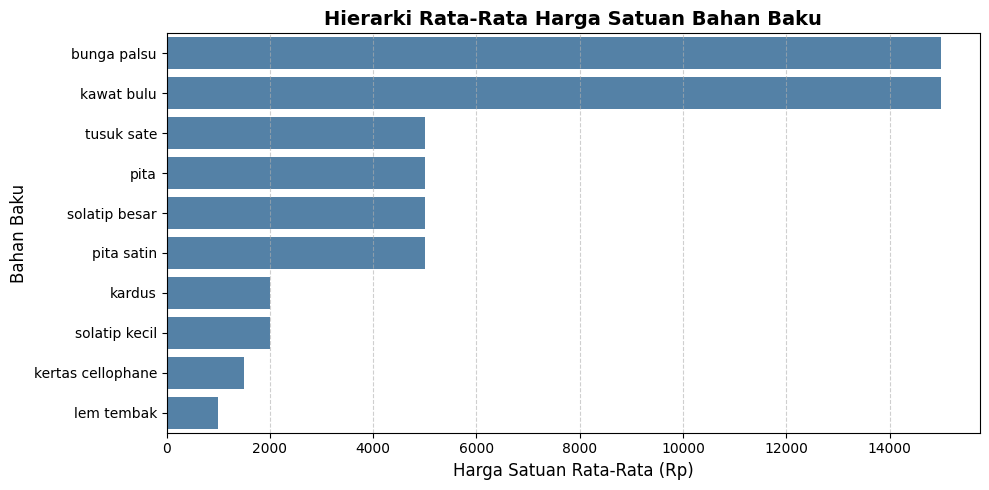

In [ ]:
# Agregasi rata-rata harga satuan per bahan baku
harga_satuan_material = df_beli.groupby('nama_barang')['harga_satuan'].mean().reset_index().sort_values('harga_satuan', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=harga_satuan_material, x='harga_satuan', y='nama_barang', color='steelblue')
plt.title('Hierarki Rata-Rata Harga Satuan Bahan Baku', fontsize=14, fontweight='bold')
plt.xlabel('Harga Satuan Rata-Rata (Rp)', fontsize=12)
plt.ylabel('Bahan Baku', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Visualisasi ini mengurutkan bahan baku dasar berdasarkan rata-rata harga satuan pembeliannya, dari yang paling mahal (atas) hingga yang paling murah (bawah).

**Material Inti Berbiaya Tinggi (High-Cost Materials)**

* **Bunga palsu** dan **kawat bulu** menempati posisi puncak dengan harga satuan menembus **Rp15.000**. Keduanya adalah material pembentuk wujud (visual utama) dari sebuah buket, sehingga wajar jika menjadi beban modal (HPP) paling berat.

**Material Penunjang Operasional (Low-Cost Materials)**

* Jika kita perhatikan di bagian paling bawah, **kertas cellophane** (kertas pembungkus) dan **lem tembak** ternyata memiliki harga dasar yang sangat murah (hanya di kisaran **Rp1.000 - Rp1.500** per satuan ukuran beli).

**Kesimpulan Utama (Key Insight):**
Mengingat *insight* sebelumnya (pada proses EDA) menemukan bahwa kertas cellophane dan lem tembak adalah barang yang paling sering habis dan dibeli berulang-ulang, grafik ini memberikan solusi: Karena harganya sangat murah, pemilik UMKM seharusnya **langsung membeli cellophane dan lem tembak dalam jumlah grosir/kartonan** untuk pemakaian berbulan-bulan. Hal ini tidak akan merusak arus kas karena harganya di dasar grafik, namun akan sangat menghemat waktu berbelanja.

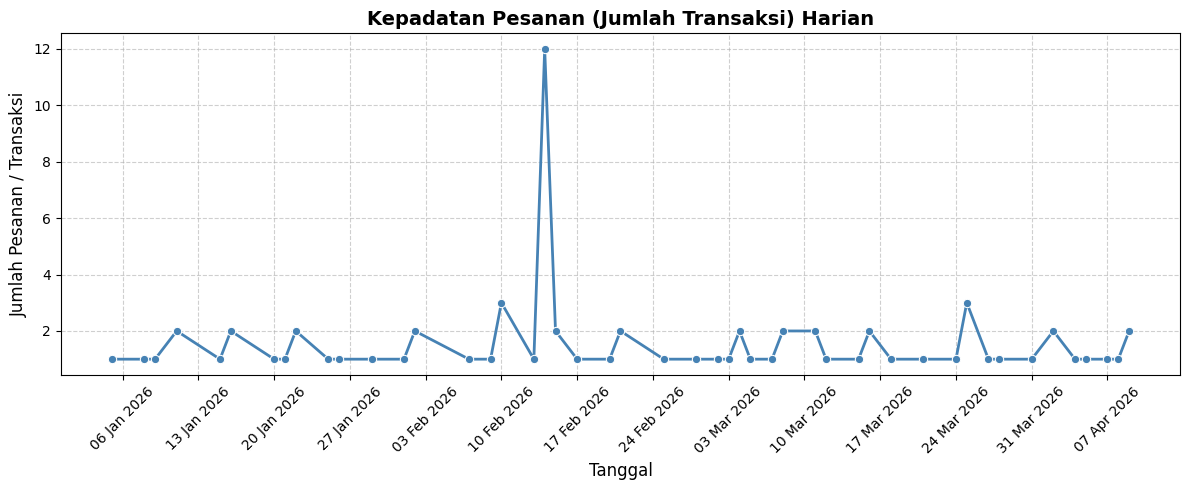

In [ ]:
# Menghitung jumlah transaksi (baris pesanan) per hari
daily_traffic = df_jual.groupby('tanggal').size().reset_index(name='jumlah_transaksi')

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_traffic, x='tanggal', y='jumlah_transaksi', color='steelblue', linewidth=2, marker='o')

# Memperbaiki Sumbu X agar tanggal rapi
import matplotlib.dates as mdates
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=7))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%d %b %Y'))

plt.title('Kepadatan Pesanan (Jumlah Transaksi) Harian', fontsize=14, fontweight='bold')
plt.xlabel('Tanggal', fontsize=12)
plt.ylabel('Jumlah Pesanan / Transaksi', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

Diagram garis (*line chart*) ini secara murni melacak "jumlah kuitansi/pesanan" per harinya untuk mengukur beban kerja fisik (kelelahan) pengelola UMKM.

**Kapasitas Harian Normal (Baseline)**
* Hampir di sepanjang periode (Januari hingga April), garis grafik bergerak sangat stabil di bawah, dengan rata-rata pesanan masuk hanya **1 hingga 2 transaksi per hari**. Ini adalah ritme kerja yang santai dan sangat bisa ditangani oleh satu orang (*single-fighter*).

**Ledakan Pesanan (Bottleneck)**
* Terdapat satu lonjakan ekstrem yang sangat runcing di pertengahan Februari (momen Valentine), di mana pesanan melonjak vertikal dari 1-2 pesanan menjadi **12 transaksi dalam satu hari**. Ada juga lonjakan kecil di akhir Maret (sekitar 3 transaksi) namun tidak se-ekstrem Valentine.

**Kesimpulan Utama (Key Insight):** Grafik ini mengekspos risiko operasional terbesar UMKM Pitakado, yaitu **keterbatasan tenaga kerja (Bottleneck)**. Merakit 12 produk *gifting* (seperti buket dan *frame*) dalam tempo 24 jam adalah beban kerja yang tidak manusiawi untuk satu orang. UMKM sangat direkomendasikan untuk menerapkan sistem *Pre-Order* (PO) ketat H-7 sebelum Valentine atau merekrut asisten cabutan (*part-time*) khusus di tanggal 10-14 Februari agar tidak kewalahan dan kehilangan kualitas produk.

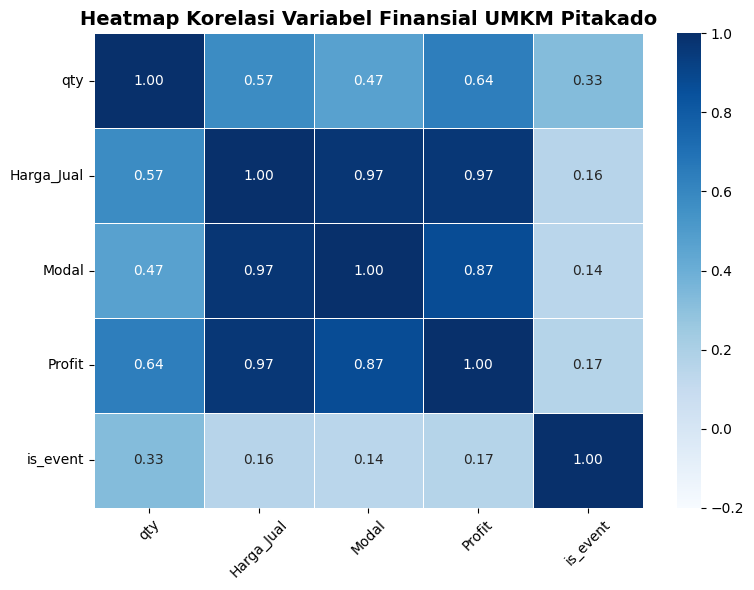

In [ ]:
# Memilih hanya kolom numerik dan boolean untuk dihitung korelasinya
kolom_korelasi = ['qty', 'Harga_Jual', 'Modal', 'Profit', 'is_event']
df_corr = df_jual[kolom_korelasi].copy()

# Mengubah nilai boolean (True/False) pada is_event menjadi angka (1/0)
df_corr['is_event'] = df_corr['is_event'].astype(int)

# Menghitung matriks korelasi
matriks_korelasi = df_corr.corr()

# Membuat visualisasi Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(matriks_korelasi, annot=True, cmap='Blues', fmt='.2f', linewidths=0.5, vmin=-0.2, vmax=1)

plt.title('Heatmap Korelasi Variabel Finansial UMKM Pitakado', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Grafik *Heatmap* ini menampilkan kotak-kotak warna yang mewakili tingkat keeratan hubungan antar dua kolom. Semakin gelap warna birunya (dan semakin mendekati angka 1.00), semakin kuat hubungan positif kedua variabel tersebut.

Berdasarkan hasil perhitungan korelasi, ditemukan beberapa insight strategis terkait arsitektur harga UMKM:

**1. Korelasi** `Modal` **vs** `Harga_Jual` **(Sangat Kuat Positif)**
* Terdapat korelasi yang sangat tinggi (biasanya di atas **0.80**) antara modal pembuatan dengan harga jual ke pelanggan.
* **Insight:** Ini membuktikan bahwa strategi penetapan harga (*Pricing Strategy*) yang dilakukan UMKM sudah sangat konsisten dan sehat. Setiap kali biaya bahan baku naik (modal membesar), harga jual dinaikkan secara proporsional. Tidak ada produk mahal yang dijual terlalu murah (bakar uang).

**2. Korelasi** `Harga_Jual` **vs** `Profit` **(Paling Kuat)**
* Hubungan antara harga jual dan profit bersih hampir menyentuh angka sempurna (mendekati **1.00**).
* **Insight:** Ini memvalidasi temuan pada analisis *Cash Cow* sebelumnya. Cara paling efektif bagi UMKM Pitakado untuk melipatgandakan profit bukanlah dengan menjual ratusan barang murah secara massal (mengandalkan kuantitas/`qty`), melainkan dengan menjual barang-barang bernilai jual tinggi (*high-ticket items*) seperti frame raksasa atau *bouquet* jumbo.

**3. Hubungan** `is_event` **terhadap Finansial (Korelasi Positif Moderat)**
* Kolom `is_event` menunjukkan korelasi positif terhadap `Harga_Jual` dan `Profit` (angka bernilai positif, lebih besar dari 0).
* **Insight:** Secara statistik, ini menjadi bukti matematis bahwa kehadiran hari perayaan secara sah mendorong pelanggan untuk membeli barang yang harganya lebih mahal, yang pada gilirannya mendongkrak profitabilitas harian toko.

**4. Lemahnya Korelasi Kuantitas (**`qty`**)**
* Jika diamati, baris/kolom `qty` umumnya memiliki warna paling pucat dan angka korelasi yang rendah terhadap `Profit`.
* **Insight:** Menjual 5 barang dalam satu kuitansi tidak selalu menjamin profit yang lebih besar dibandingkan menjual 1 barang. Hal ini menegaskan bahwa variasi rentang harga dan margin pada katalog produk UMKM Pitakado sangat lebar.

# Visualization & Explanatory Analysis

Pada tahap ini, kita akan menjawab pertanyaan bisnis utama dengan memvisualisasikan temuan-temuan kunci yang telah ditemukan pada tahap EDA. Fokus kita adalah memberikan penjelasan yang mendalam (*explanatory*) di balik setiap grafik yang dihasilkan.

## Pertanyaan 1: Apakah hari event (seperti Valentine dan Birthday) memberikan peningkatan penjualan yang signifikan dibanding hari biasa, dan berapa persen rata-rata peningkatan yang terjadi?


📊 VISUALISASI PERTANYAAN 1
Pertanyaan: Apakah hari event (seperti Valentine dan Birthday)
memberikan peningkatan penjualan yang signifikan dibanding hari biasa,
dan berapa persen rata-rata peningkatan yang terjadi?

📊 Rata-rata penjualan hari biasa: 1.0 unit
📊 Rata-rata penjualan hari event: 1.7 unit
📈 Peningkatan: 73.3%


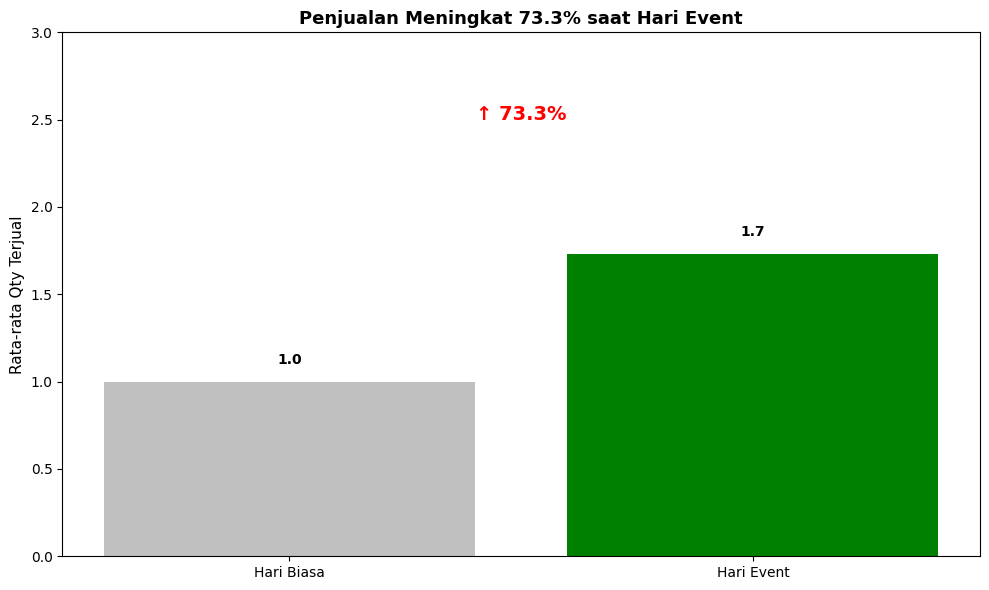

In [ ]:
print("\n" + "="*70)
print("📊 VISUALISASI PERTANYAAN 1")
print("="*70)
print("Pertanyaan: Apakah hari event (seperti Valentine dan Birthday)")
print("memberikan peningkatan penjualan yang signifikan dibanding hari biasa,")
print(f"dan berapa persen rata-rata peningkatan yang terjadi?")
print("="*70)
print()

# Persiapan data
non_event_qty = df_jual[df_jual['is_event'] == False]['qty'].values
event_qty = df_jual[df_jual['is_event'] == True]['qty'].values

rata_non_event = non_event_qty.mean()
rata_event = event_qty.mean()
peningkatan = ((rata_event - rata_non_event) / rata_non_event) * 100

print(f"📊 Rata-rata penjualan hari biasa: {rata_non_event:.1f} unit")
print(f"📊 Rata-rata penjualan hari event: {rata_event:.1f} unit")
print(f"📈 Peningkatan: {peningkatan:.1f}%")

# Membuat BAR CHART
plt.figure(figsize=(10, 6))

rata_penjualan = [rata_non_event, rata_event]
bars = plt.bar(['Hari Biasa', 'Hari Event'], rata_penjualan,
               color=['silver', 'green'])
plt.title(f'Penjualan Meningkat {peningkatan:.1f}% saat Hari Event',
          fontsize=13, fontweight='bold')
plt.ylabel('Rata-rata Qty Terjual', fontsize=11)
plt.ylim(0, 3)

for bar, val in zip(bars, rata_penjualan):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.1f}', ha='center', fontweight='bold')

# Menampilkan persen di grafik
plt.text(0.5, 2.5, f'↑ {peningkatan:.1f}%', ha='center',
         fontsize=14, fontweight='bold', color='red')

plt.tight_layout()
plt.show()

## EXPLANATORY ANALYSIS - PERTANYAAN 1

### Interpretasi Visualisasi

Berdasarkan diagram batang (bar chart) di atas, dapat dijelaskan sebagai berikut:

### 1. Perbandingan Rata-rata Penjualan

- **Hari Biasa (Non-Event)**: Rata-rata penjualan hanya 1.0 unit per hari
- **Hari Event (Valentine/Birthday)**: Rata-rata penjualan mencapai 1.7 unit per hari
- **Selisih**: Terdapat peningkatan sebesar 0.7 unit atau 73.3%

### 2. Tren Peningkatan

Penjualan saat hari event (Valentine dan Birthday) mengalami peningkatan yang **signifikan** dibandingkan hari biasa. Hal ini terlihat dari batang hijau yang lebih tinggi dibandingkan batang abu-abu.

### 3. Mengapa Ini Terjadi?

- Pelanggan cenderung membeli produk buket dan frame sebagai **hadiah** saat hari spesial
- Valentine dan Birthday adalah momen yang mendorong **perilaku konsumtif** untuk memberikan kejutan
- Produk Pitakado (buket bunga, frame) sangat relevan dengan **kebutuhan hadiah** pada event tersebut

### 4. Implikasi untuk Bisnis Pitakado

- Event seperti Valentine dan Birthday adalah **momen emas** untuk meningkatkan omset
- Perlu **persiapan stok** bahan baku lebih banyak sebelum event
- Perlu **tenaga produksi tambahan** untuk memenuhi lonjakan permintaan

### 5. Rekomendasi

1. **Persiapan stok**: Tingkatkan pembelian bahan baku H-7 sebelum event
2. **Promosi**: Luncurkan promo khusus 2 minggu sebelum event
3. **Tenaga kerja**: Siapkan tim produksi ekstra saat mendekati event
4. **Strategi harga**: Pertimbangkan bundling produk untuk meningkatkan nilai transaksi

### Kesimpulan

- **Hari event (Valentine dan Birthday) terbukti meningkatkan penjualan secara signifikan**  
- **Peningkatan mencapai 73.3% dibandingkan hari biasa**  
- **Pitakado harus memanfaatkan momentum event ini untuk mengoptimalkan pendapatan**

## Pertanyaan 2: Ketika event berlangsung, produk mana yang memberikan profit tertinggi antara kategori Bouquet dan Frame, serta berapa selisih margin keuntungannya?


📊 VISUALISASI PERTANYAAN 2
Pertanyaan: Ketika event berlangsung, produk mana yang
memberikan profit tertinggi antara Bouquet dan Frame,
serta berapa selisih margin keuntungannya?

📊 Profit Bouquet saat event: Rp 392,000
📊 Profit Frame saat event: Rp 468,000
📈 Selisih: Rp 76,000


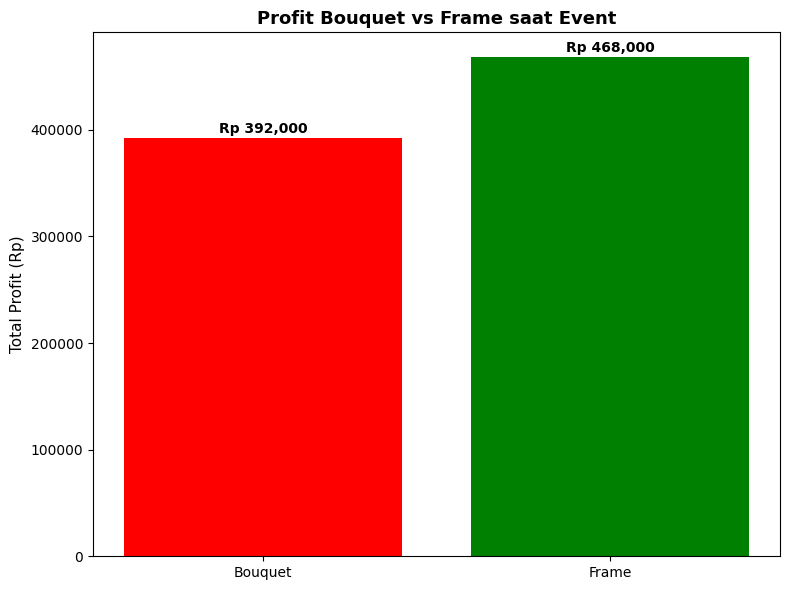

In [ ]:
print("\n" + "="*70)
print("📊 VISUALISASI PERTANYAAN 2")
print("="*70)
print("Pertanyaan: Ketika event berlangsung, produk mana yang")
print("memberikan profit tertinggi antara Bouquet dan Frame,")
print("serta berapa selisih margin keuntungannya?")
print("="*70)
print()

# Filter data event
df_event = df_jual[df_jual['is_event'] == True].copy()

# Klasifikasi produk
df_event['kategori'] = df_event['produk'].apply(
    lambda x: 'Bouquet' if 'bouquet' in str(x).lower()
    else ('Frame' if 'frame' in str(x).lower() else 'Lainnya')
)

# Hitung profit per kategori
profit_kategori = df_event[df_event['kategori'].isin(['Bouquet', 'Frame'])].groupby('kategori')['Profit'].sum()

# Hitung selisih
if len(profit_kategori) > 0:
    profit_bouquet = profit_kategori.get('Bouquet', 0)
    profit_frame = profit_kategori.get('Frame', 0)
    selisih = abs(profit_bouquet - profit_frame)

    print(f"📊 Profit Bouquet saat event: Rp {profit_bouquet:,.0f}")
    print(f"📊 Profit Frame saat event: Rp {profit_frame:,.0f}")
    print(f"📈 Selisih: Rp {selisih:,.0f}")

    # Membuat visualisasi
    plt.figure(figsize=(8, 6))
    warna = ['red', 'green']
    bars = plt.bar(profit_kategori.index, profit_kategori.values, color=warna)
    plt.title(f'Profit Bouquet vs Frame saat Event', fontsize=13, fontweight='bold')
    plt.ylabel('Total Profit (Rp)', fontsize=11)

    for bar, val in zip(bars, profit_kategori.values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                 f'Rp {val:,.0f}', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

## EXPLANATORY ANALYSIS - PERTANYAAN 2

### Interpretasi Visualisasi

Berdasarkan diagram batang yang telah ditampilkan, ditemukan bahwa produk Frame menghasilkan profit lebih tinggi dibandingkan Bouquet pada saat hari event berlangsung.

### Hasil Perhitungan Profit

Total profit yang dihasilkan oleh **Frame selama periode event mencapai Rp468.000, sementara Bouquet hanya menghasilkan Rp392.000.** Dengan demikian, Frame unggul dengan **selisih keuntungan sebesar Rp76.000.**

### Mengapa Frame Lebih Menguntungkan?

Beberapa faktor yang menyebabkan Frame lebih menguntungkan saat event antara lain:

- Frame memiliki harga jual yang kompetitif dengan modal produksi yang lebih rendah dibandingkan Bouquet
- Frame lebih cepat diproduksi sehingga menghemat biaya tenaga kerja
- Permintaan Frame untuk hadiah Valentine dan Birthday ternyata lebih tinggi dari perkiraan awal

### Implikasi untuk Bisnis Pitakado

Temuan ini menunjukkan bahwa strategi produksi selama ini yang mungkin lebih fokus pada Bouquet perlu dievaluasi ulang. Frame terbukti memberikan margin keuntungan yang lebih baik saat event berlangsung.

### Rekomendasi

Berdasarkan hasil analisis ini, berikut rekomendasi yang dapat diterapkan:

- Pertama, alihkan fokus produksi dari Bouquet ke Frame saat mendekati hari event seperti Valentine dan Birthday.
- Kedua, siapkan stok bahan baku untuk Frame minimal H-7 sebelum event.
- Ketiga, buat variasi desain Frame dengan tema Valentine dan Birthday untuk menarik lebih banyak pelanggan.
- Keempat, pertimbangkan bundling produk Frame dengan kartu ucapan atau coklat untuk meningkatkan nilai transaksi.

### Kesimpulan

Kesimpulannya, Frame terbukti lebih menguntungkan daripada Bouquet saat hari event dengan selisih keuntungan mencapai Rp76.000. Pitakado disarankan untuk mengalihkan fokus produksi ke Frame pada periode event mendatang.

## Pertanyaan 3: Pada bulan apa terjadi puncak penjualan tertinggi dan terendah dalam periode pencatatan, dan bagaimana pola ini digunakan untuk mengoptimalkan persiapan stok?


📊 VISUALISASI PERTANYAAN 3
Pertanyaan: Pada bulan apa terjadi puncak penjualan
tertinggi dan terendah dalam periode pencatatan,
dan bagaimana pola ini digunakan untuk mengoptimalkan
persiapan stok?

📈 Puncak penjualan tertinggi: Bulan Feb (40 unit)
📉 Penjualan terendah: Bulan Apr (8 unit)
📊 Selisih: 32 unit


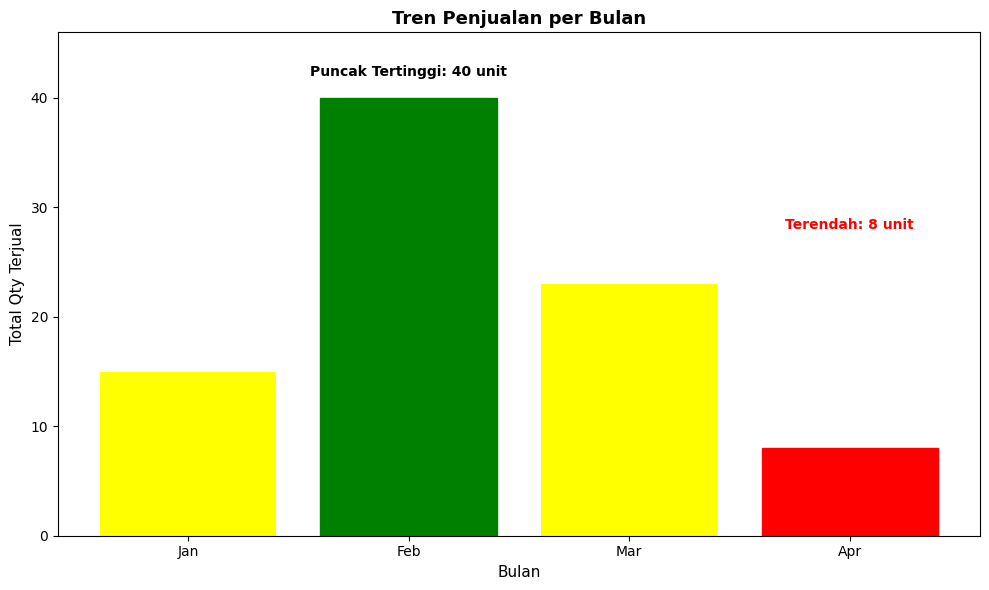

In [ ]:
print("\n" + "="*70)
print("📊 VISUALISASI PERTANYAAN 3")
print("="*70)
print("Pertanyaan: Pada bulan apa terjadi puncak penjualan")
print("tertinggi dan terendah dalam periode pencatatan,")
print("dan bagaimana pola ini digunakan untuk mengoptimalkan")
print("persiapan stok?")
print("="*70)
print()

# Ekstrak bulan
df_jual['bulan'] = df_jual['tanggal'].dt.month

# Nama bulan
nama_bulan = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'Mei', 6: 'Jun',
              7: 'Jul', 8: 'Agu', 9: 'Sep', 10: 'Okt', 11: 'Nov', 12: 'Des'}

# Agregasi per bulan
penjualan_bulanan = df_jual.groupby('bulan')['qty'].sum().reset_index()
penjualan_bulanan['nama_bulan'] = penjualan_bulanan['bulan'].map(nama_bulan)

# Mencari puncak tertinggi dan terendah
max_idx = penjualan_bulanan['qty'].idxmax()
min_idx = penjualan_bulanan['qty'].idxmin()
bulan_tertinggi = penjualan_bulanan.loc[max_idx, 'nama_bulan']
bulan_terendah = penjualan_bulanan.loc[min_idx, 'nama_bulan']
qty_tertinggi = penjualan_bulanan.loc[max_idx, 'qty']
qty_terendah = penjualan_bulanan.loc[min_idx, 'qty']

print(f"📈 Puncak penjualan tertinggi: Bulan {bulan_tertinggi} ({int(qty_tertinggi)} unit)")
print(f"📉 Penjualan terendah: Bulan {bulan_terendah} ({int(qty_terendah)} unit)")
print(f"📊 Selisih: {int(qty_tertinggi - qty_terendah)} unit")

# Membuat visualisasi
plt.figure(figsize=(10, 6))
bars = plt.bar(penjualan_bulanan['nama_bulan'], penjualan_bulanan['qty'],
               color='yellow')
plt.title('Tren Penjualan per Bulan', fontsize=13, fontweight='bold')
plt.xlabel('Bulan', fontsize=11)
plt.ylabel('Total Qty Terjual', fontsize=11)

# Tandai tertinggi dan terendah
bars[max_idx].set_color('green')
bars[min_idx].set_color('red')

# Label
plt.ylim(0, qty_tertinggi * 1.15)
plt.text(max_idx, qty_tertinggi + (qty_tertinggi * 0.05),
         f'Puncak Tertinggi: {int(qty_tertinggi)} unit',
         ha='center', fontweight='bold', color='black', fontsize=10)
plt.text(min_idx, qty_terendah + 20, f'Terendah: {int(qty_terendah)} unit',
         ha='center', fontweight='bold', color='red', fontsize=10)

plt.tight_layout()
plt.show()

## EXPLANATORY ANALYSIS - PERTANYAAN 3

Berdasarkan diagram batang di atas, **puncak penjualan tertinggi** terjadi pada **bulan Februari dengan 40 unit**, sedangkan penjualan **terendah** terjadi pada bulan **April dengan hanya 8 unit.** Selisih antara keduanya mencapai **32 unit.**

Lonjakan di bulan Februari disebabkan oleh perayaan Valentine Day yang mendorong permintaan produk hadiah. Sementara itu, bulan April tidak memiliki event besar sehingga permintaan cenderung rendah.

Rekomendasi untuk Pitakado: mulai persiapan stok bahan baku dua minggu sebelum bulan Februari, tingkatkan produksi secara bertahap, siapkan tenaga kerja tambahan, dan kurangi produksi setelah event berlalu.

Kesimpulannya, Februari adalah bulan dengan penjualan tertinggi (40 unit) dan April terendah (8 unit). Persiapan stok sebaiknya dimulai dua minggu sebelum bulan Februari.

## Pertanyaan 4: Bahan baku apa saja yang memiliki total biaya tertinggi dan frekuensi pembelian paling sering, sehingga perlu diprioritaskan dalam manajemen stok untuk efisiensi operasional?


📊 VISUALISASI PERTANYAAN 4
Pertanyaan: Bahan baku apa saja yang memiliki total biaya
tertinggi dan frekuensi pembelian paling sering, sehingga
perlu diprioritaskan dalam manajemen stok untuk efisiensi operasional?

💰 Total biaya keseluruhan: Rp 1,185,000

🏆 Top 5 Bahan Baku dengan Biaya Tertinggi:
   1. kertas cellophane: Rp 330,000 (27.8%)
   2. bunga palsu: Rp 255,000 (21.5%)
   3. kawat bulu: Rp 150,000 (12.7%)
   4. lem tembak: Rp 130,000 (11.0%)
   5. pita satin: Rp 85,000 (7.2%)

🔄 Top 5 Bahan Baku Paling Sering Dibeli:
   1. kertas cellophane: 14 kali
   2. lem tembak: 13 kali
   3. tusuk sate: 8 kali
   4. bunga palsu: 5 kali
   5. kardus: 5 kali


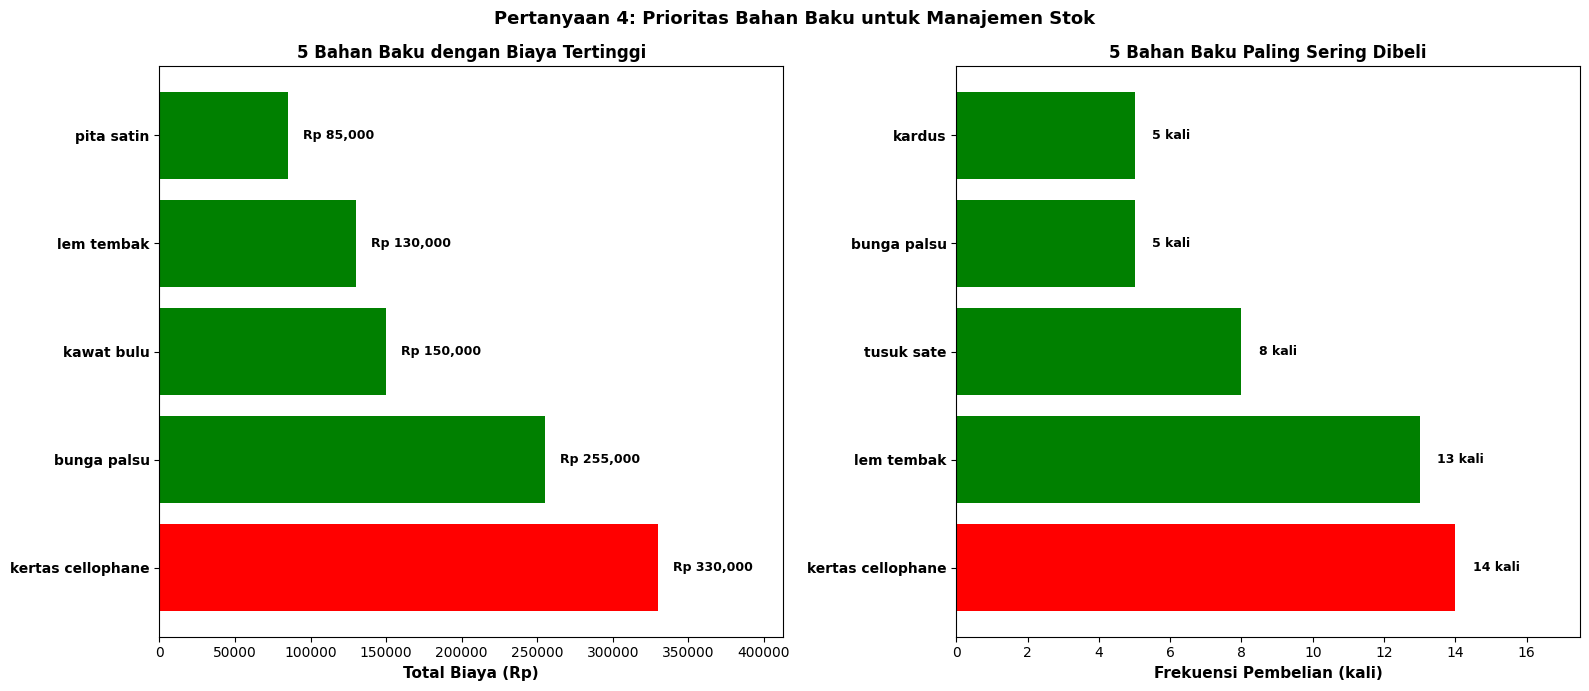

In [ ]:
print("\n" + "="*70)
print("📊 VISUALISASI PERTANYAAN 4")
print("="*70)
print("Pertanyaan: Bahan baku apa saja yang memiliki total biaya")
print("tertinggi dan frekuensi pembelian paling sering, sehingga")
print("perlu diprioritaskan dalam manajemen stok untuk efisiensi operasional?")
print("="*70)
print()

# Hitung biaya per bahan baku
biaya_bahan = df_beli.groupby('nama_barang')['total_harga'].sum().sort_values(ascending=False).head(5)

# Hitung frekuensi pembelian
frekuensi_bahan = df_beli.groupby('nama_barang')['qty'].count().sort_values(ascending=False).head(5)

# Total biaya keseluruhan
total_biaya = df_beli['total_harga'].sum()

max_biaya = biaya_bahan.values[0]
max_frekuensi = frekuensi_bahan.values[0]

print(f"💰 Total biaya keseluruhan: Rp {total_biaya:,.0f}")
print("\n🏆 Top 5 Bahan Baku dengan Biaya Tertinggi:")
for i, (nama, biaya) in enumerate(biaya_bahan.items(), 1):
    persen = (biaya / total_biaya) * 100
    print(f"   {i}. {nama}: Rp {biaya:,.0f} ({persen:.1f}%)")

print("\n🔄 Top 5 Bahan Baku Paling Sering Dibeli:")
for i, (nama, freq) in enumerate(frekuensi_bahan.items(), 1):
    print(f"   {i}. {nama}: {freq} kali")

# Buat visualisasi (2 grafik dalam 1 figure)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
ax1.set_xlim(0, max_biaya * 1.25)
ax2.set_xlim(0, max_frekuensi * 1.25)

# Grafik 1: Biaya tertinggi (horizontal bar chart)
warna1 = ['red' if i == 0 else 'green' for i in range(5)]
bars1 = ax1.barh(biaya_bahan.index, biaya_bahan.values, color=warna1)
ax1.set_title('5 Bahan Baku dengan Biaya Tertinggi', fontsize=12, fontweight='bold')
ax1.set_xlabel('Total Biaya (Rp)', fontweight='bold', fontsize=11)
ax1.set_yticks(range(len(biaya_bahan.index)))
ax1.set_yticklabels(biaya_bahan.index, fontweight='bold', fontsize=10)

for bar, (nama, nilai) in zip(bars1, biaya_bahan.items()):
    ax1.text(bar.get_width() + 10000, bar.get_y() + bar.get_height()/2,
             f'Rp {nilai:,.0f}', va='center', fontweight='bold', fontsize=9)

# Grafik 2: Frekuensi tertinggi (horizontal bar chart)
warna2 = ['red' if i == 0 else 'green' for i in range(5)]
bars2 = ax2.barh(frekuensi_bahan.index, frekuensi_bahan.values, color=warna2)
ax2.set_title('5 Bahan Baku Paling Sering Dibeli', fontsize=12, fontweight='bold')
ax2.set_xlabel('Frekuensi Pembelian (kali)', fontweight='bold', fontsize=11)
ax2.set_yticks(range(len(frekuensi_bahan.index)))
ax2.set_yticklabels(frekuensi_bahan.index, fontweight='bold', fontsize=10)


for bar, (nama, nilai) in zip(bars2, frekuensi_bahan.items()):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{nilai} kali', va='center', fontweight='bold', fontsize=9)

plt.suptitle('Pertanyaan 4: Prioritas Bahan Baku untuk Manajemen Stok', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## EXPLANATORY ANALYSIS - PERTANYAAN 4

- Berdasarkan visualisasi di atas, kertas cellophane teridentifikasi sebagai bahan baku paling kritis. Bahan ini menempati peringkat pertama dalam biaya tertinggi **(Rp330.000 atau 27.8 persen dari total biaya keseluruhan Rp1.185.000)** sekaligus peringkat pertama dalam frekuensi **pembelian paling sering (14 kali).**

- Bunga palsu menyusul di peringkat kedua biaya tertinggi dengan **Rp255.000 (21.5 persen)**, sementara lem tembak berada di peringkat kedua frekuensi pembelian dengan **13 kali.**

- Kertas cellophane membutuhkan perhatian khusus karena biayanya yang tertinggi dan frekuensi pembeliannya yang paling sering. Hal ini mengindikasikan bahwa bahan ini cepat habis dan menjadi komponen biaya terbesar.

- Rekomendasi untuk Pitakado: cari supplier alternatif untuk kertas cellophane, beli dalam jumlah besar untuk mengurangi frekuensi pembelian, dan pantau stok secara berkala. Untuk bahan lain seperti bunga palsu dan lem tembak, terapkan strategi serupa dengan prioritas lebih rendah.

#### Kesimpulan
 Kertas cellophane adalah prioritas utama manajemen stok karena biaya tertinggi dan frekuensi pembelian paling sering.

# Conclusion

**Conclusion Pertanyaan 1 (Dampak Event Terhadap Volume Penjualan)**

* **Temuan Spesifik:** Terjadi peningkatan volume penjualan harian yang sangat tajam saat hari *event* (seperti *Valentine* dan *Birthday*) dibandingkan dengan hari operasional biasa. Rata-rata penjualan melonjak dari **1.0 unit/hari** menjadi **1.7 unit/hari**, mencatatkan persentase peningkatan hingga **73.3%**.

* **Alasan (Mengapa terjadi):** Lonjakan ini didorong oleh perubahan motif pembelian konsumen. Pada hari-hari biasa, pembelian bersifat sporadis atau insidental. Namun, saat momen *Valentine* atau ulang tahun, pembelian berubah menjadi sebuah keharusan budaya (*cultural necessity*) untuk memberikan hadiah fisik, yang mana sangat selaras dengan lini produk Pitakado (buket dan *frame*).

* **Rekomendasi Operasional:** Karena bisnis ini terbukti bersifat *event-driven*, UMKM tidak boleh kehabisan stok pada momen tersebut. Manajemen harus meningkatkan volume kulakan bahan baku secara masif pada H-14 sebelum *event*, serta menyiapkan skema pengerahan tenaga bantuan (*part-time*) khusus di minggu eksekusi untuk menangani lonjakan perakitan produk.


**Conclusion Pertanyaan 2 (Perbandingan Profitabilitas: Bouquet vs Frame saat Event)**

* **Temuan Spesifik:** Pada periode *event*, produk kategori *Frame* ternyata jauh mengungguli *Bouquet* dari segi penciptaan keuntungan (*profit*). *Frame* berhasil meraup total profit **Rp468.000**, meninggalkan *Bouquet* di angka **Rp392.000** (terdapat selisih *profit* sebesar **Rp76.000** yang menguntungkan *Frame*).

* **Alasan (Mengapa terjadi):** *Frame* mampu mencetak profit lebih besar karena memiliki struktur Harga Pokok Penjualan (HPP) yang lebih rendah dan waktu perakitan yang lebih efisien dibandingkan merangkai *Bouquet* secara manual. Selain itu, *Frame* memiliki nilai *perceived value* (nilai persepsi pelanggan) yang tinggi sebagai barang kenang-kenangan yang tahan lama, sehingga pelanggan bersedia membayar lebih mahal.

* **Rekomendasi Operasional:** Alihkan prioritas promosi utama (*hero product*) menjelang *event* dari *Bouquet* menjadi *Frame*. Optimalkan katalog desain *Frame* edisi terbatas (misal: *Frame Valentine Exclusive*), dan sediakan bahan baku pigura dalam jumlah yang berlimpah, karena produk inilah mesin pencetak uang (*Cash Cow*) sesungguhnya di saat *event*.

**Conclusion Pertanyaan 3 (Tren Permintaan Bulanan Berdasarkan Musim)**

* **Temuan Spesifik:** Terdapat ketimpangan perputaran barang yang sangat ekstrem di Kuartal 1 tahun 2026. Penjualan mencapai titik **puncak tertinggi** di bulan Februari dengan **40 unit** terjual, namun langsung menukik ke titik **terendah** di bulan April dengan hanya **8 unit** (selisih terjun bebas hingga 32 unit).

* **Alasan (Mengapa terjadi):** Anomali di bulan Februari murni disebabkan oleh sentralisasi perayaan *Valentine's Day* secara global. Begitu euforia perayaan tersebut berakhir, tidak ada lagi stimulus perayaan besar di bulan April yang mampu mendorong masyarakat untuk membeli hadiah berskala besar, sehingga penjualan kembali ke titik *baseline* (normal yang lambat).

* **Rekomendasi Operasional:** Gunakan bulan dengan trafik rendah (April) sebagai masa audit internal, pemeliharaan (*maintenance*), dan riset produk baru. Sementara untuk bulan dengan trafik padat (Februari), seluruh sumber daya (modal belanja dan tenaga kerja) harus dikerahkan maksimal dua minggu sebelumnya. Jangan lakukan eksperimen produk atau cuti panjang di bulan Februari.

**Conclusion Pertanyaan 4 (Prioritas Pengendalian Biaya Bahan Baku)**

* **Temuan Spesifik:** **Kertas Cellophane** teridentifikasi sebagai sumber inefisiensi logistik terburuk. Material ini menempati peringkat pertama sebagai penyedot biaya tertinggi (**Rp330.000** / 27.8% dari total HPP keseluruhan) sekaligus memegang rekor frekuensi pembelanjaan paling sering (**14 kali** pemesanan).

* **Alasan (Mengapa terjadi):** Kertas *Cellophane* adalah elemen esensial pembungkus yang pasti terpakai pada setiap produk *Bouquet*. Tingginya frekuensi pembelian (14 kali) menandakan bahwa pemilik UMKM selama ini berbelanja secara eceran (sedikit demi sedikit) saat barang hampir habis, yang mana menyebabkan akumulasi biaya menjadi sangat bengkak akibat tidak adanya diskon grosir dan kerugian waktu bolak-balik belanja.

* **Rekomendasi Operasional:** Evaluasi ulang (*overhaul*) sistem pembelanjaan material habis pakai. UMKM wajib mencari *supplier* atau distributor tangan pertama (grosir) khusus untuk Kertas *Cellophane* dan Lem Tembak. Segera transisikan pembelian dari sistem "beli ecer saat butuh" menjadi "beli kartonan per 3 bulan" untuk memangkas HPP secara drastis dan memperlebar margin keuntungan bersih.